## 1. Introduction

### Background and Problem Context
Modern data-driven applications require fast retrieval and update operations even when the table size grows from hundreds to tens of thousands of records. A naive storage strategy based on linear scanning can be simple to implement, but it often becomes a performance bottleneck for operations such as point search, range filtering, and repeated updates. In database systems, this problem is typically solved using index structures that keep access time predictable as data grows.

### Problem Statement
The key challenge addressed in this project is to design a lightweight database layer that supports core table operations efficiently:
- Insertion of new records
- Search by key
- Deletion of records
- Range query over key intervals

The baseline (brute-force) approach performs many of these operations with linear-time behavior in practice. As the dataset grows, this can lead to higher latency and poor scalability.

### Proposed Solution: B+ Tree Based DBMS
This project proposes a B+ Tree based DBMS architecture where records are indexed by a primary key. The B+ Tree is a balanced multi-way search tree that is widely used in database engines because it combines fast lookup with efficient ordered traversal.

Key properties that make B+ Trees suitable for this project:
- Logarithmic search and update complexity due to balanced height
- Ordered keys in leaf nodes for efficient range queries
- Leaf-level linkage for sequential scans across key intervals
- Stable performance under growth compared with linear scanning

### Project Objective
The objective is not only to implement B+ Tree operations, but also to evaluate them empirically against a brute-force backend. The report therefore includes both correctness validation and benchmarking-based analysis, so conclusions are grounded in observed data rather than theory alone.

## 2. Setup and Imports

Run this cell first to load all required modules and define paths used in the report.

In [2]:
from pathlib import Path
import importlib
import pandas as pd

from bplustree import BPlusTree
import performance_analyzer as performance_analyzer_module

# Reload to ensure the notebook uses latest module changes
importlib.reload(performance_analyzer_module)
PerformanceAnalyzer = performance_analyzer_module.PerformanceAnalyzer

BASE_DIR = Path('.').resolve()
VIS_DIR = BASE_DIR / 'visualizations'

print('Base directory:', BASE_DIR)
print('Visualizations directory:', VIS_DIR)

Base directory: D:\AKASH.O\Downloads\DB_A2\Module_A\database
Visualizations directory: D:\AKASH.O\Downloads\DB_A2\Module_A\database\visualizations


## 3. Implementation Details

### 3.1 Data Structure Design
The implementation uses a classic B+ Tree layout with two logical node types:
- Internal nodes: store separator keys and child pointers used for routing
- Leaf nodes: store actual key-record mappings in sorted order

Unlike binary search trees, B+ Trees maintain high fan-out (multiple children per internal node), which reduces overall tree height and improves lookup/update efficiency. All data records are kept at the leaf level, enabling uniform search termination and efficient ordered traversal.

### 3.2 Insertion Workflow
Insertion follows a top-down traversal to locate the target leaf, then inserts the key in sorted position. If the node exceeds allowed capacity, a split operation is performed:
1. Divide keys into two nodes
2. Promote a separator key to the parent
3. Recursively split upward if the parent also overflows

This process preserves B+ Tree invariants: balanced height, sorted keys, and valid key ranges per subtree.

### 3.3 Search Workflow
Search begins at the root and uses separator comparisons to choose child branches until a leaf is reached. The leaf is then checked for exact key match. Because the tree is balanced, path length remains small relative to dataset size, giving predictable lookup performance.

### 3.4 Deletion Workflow
Deletion removes a key from the appropriate leaf node. If deletion causes underflow, the tree attempts structural repair through:
- Redistribution: borrow key(s) from a sibling
- Merge: combine with sibling when redistribution is not possible
- Parent update: adjust separator keys and potentially propagate structural changes upward

This ensures tree consistency after removals while keeping height balanced.

### 3.5 Range Query Workflow
Range queries use a two-phase approach:
1. Navigate to the leaf containing the lower bound
2. Traverse across linked leaves until the upper bound is exceeded

Because leaves are linked in key order, range retrieval avoids repeated root traversal and is significantly more efficient than repeated point lookups.

### 3.6 DBMS Layer Integration
The tree is wrapped by table/database management abstractions, allowing schema-aware operations similar to a minimal DBMS API. Each table defines:
- Schema (field names and types)
- Search key (indexed attribute)
- CRUD-like operations exposed through manager classes

This separation keeps indexing logic modular while enabling higher-level database workflows in notebook tests and benchmarks.

## 4. Functional Validation Snapshot

This optional quick check demonstrates that insertion, search, delete, and range query work on a small sample.

In [3]:
tree = BPlusTree(order=6)
for k in range(1, 21):
    tree.insert(k, {'id': k, 'value': f'record_{k}'})

sample_search = tree.search(10)
sample_range = tree.range_query(7, 12)
_ = tree.delete(8)
post_delete = tree.search(8)

print('Search key=10:', sample_search)
print('Range 7-12 count:', len(sample_range))
print('Search key=8 after delete:', post_delete)

Search key=10: {'id': 10, 'value': 'record_10'}
Range 7-12 count: 6
Search key=8 after delete: None


## 5. Performance Analysis

The benchmark compares B+ Tree and brute-force implementations over multiple data sizes for insert, search, range query, and delete operations.

### 5.1 Full Benchmark Plots (Stored Results)

The following cell loads benchmark charts already saved in the local `plot`/`plots` directory.

Showing images from: D:\AKASH.O\Downloads\DB_A2\Module_A\database\plots


#### Performance Time

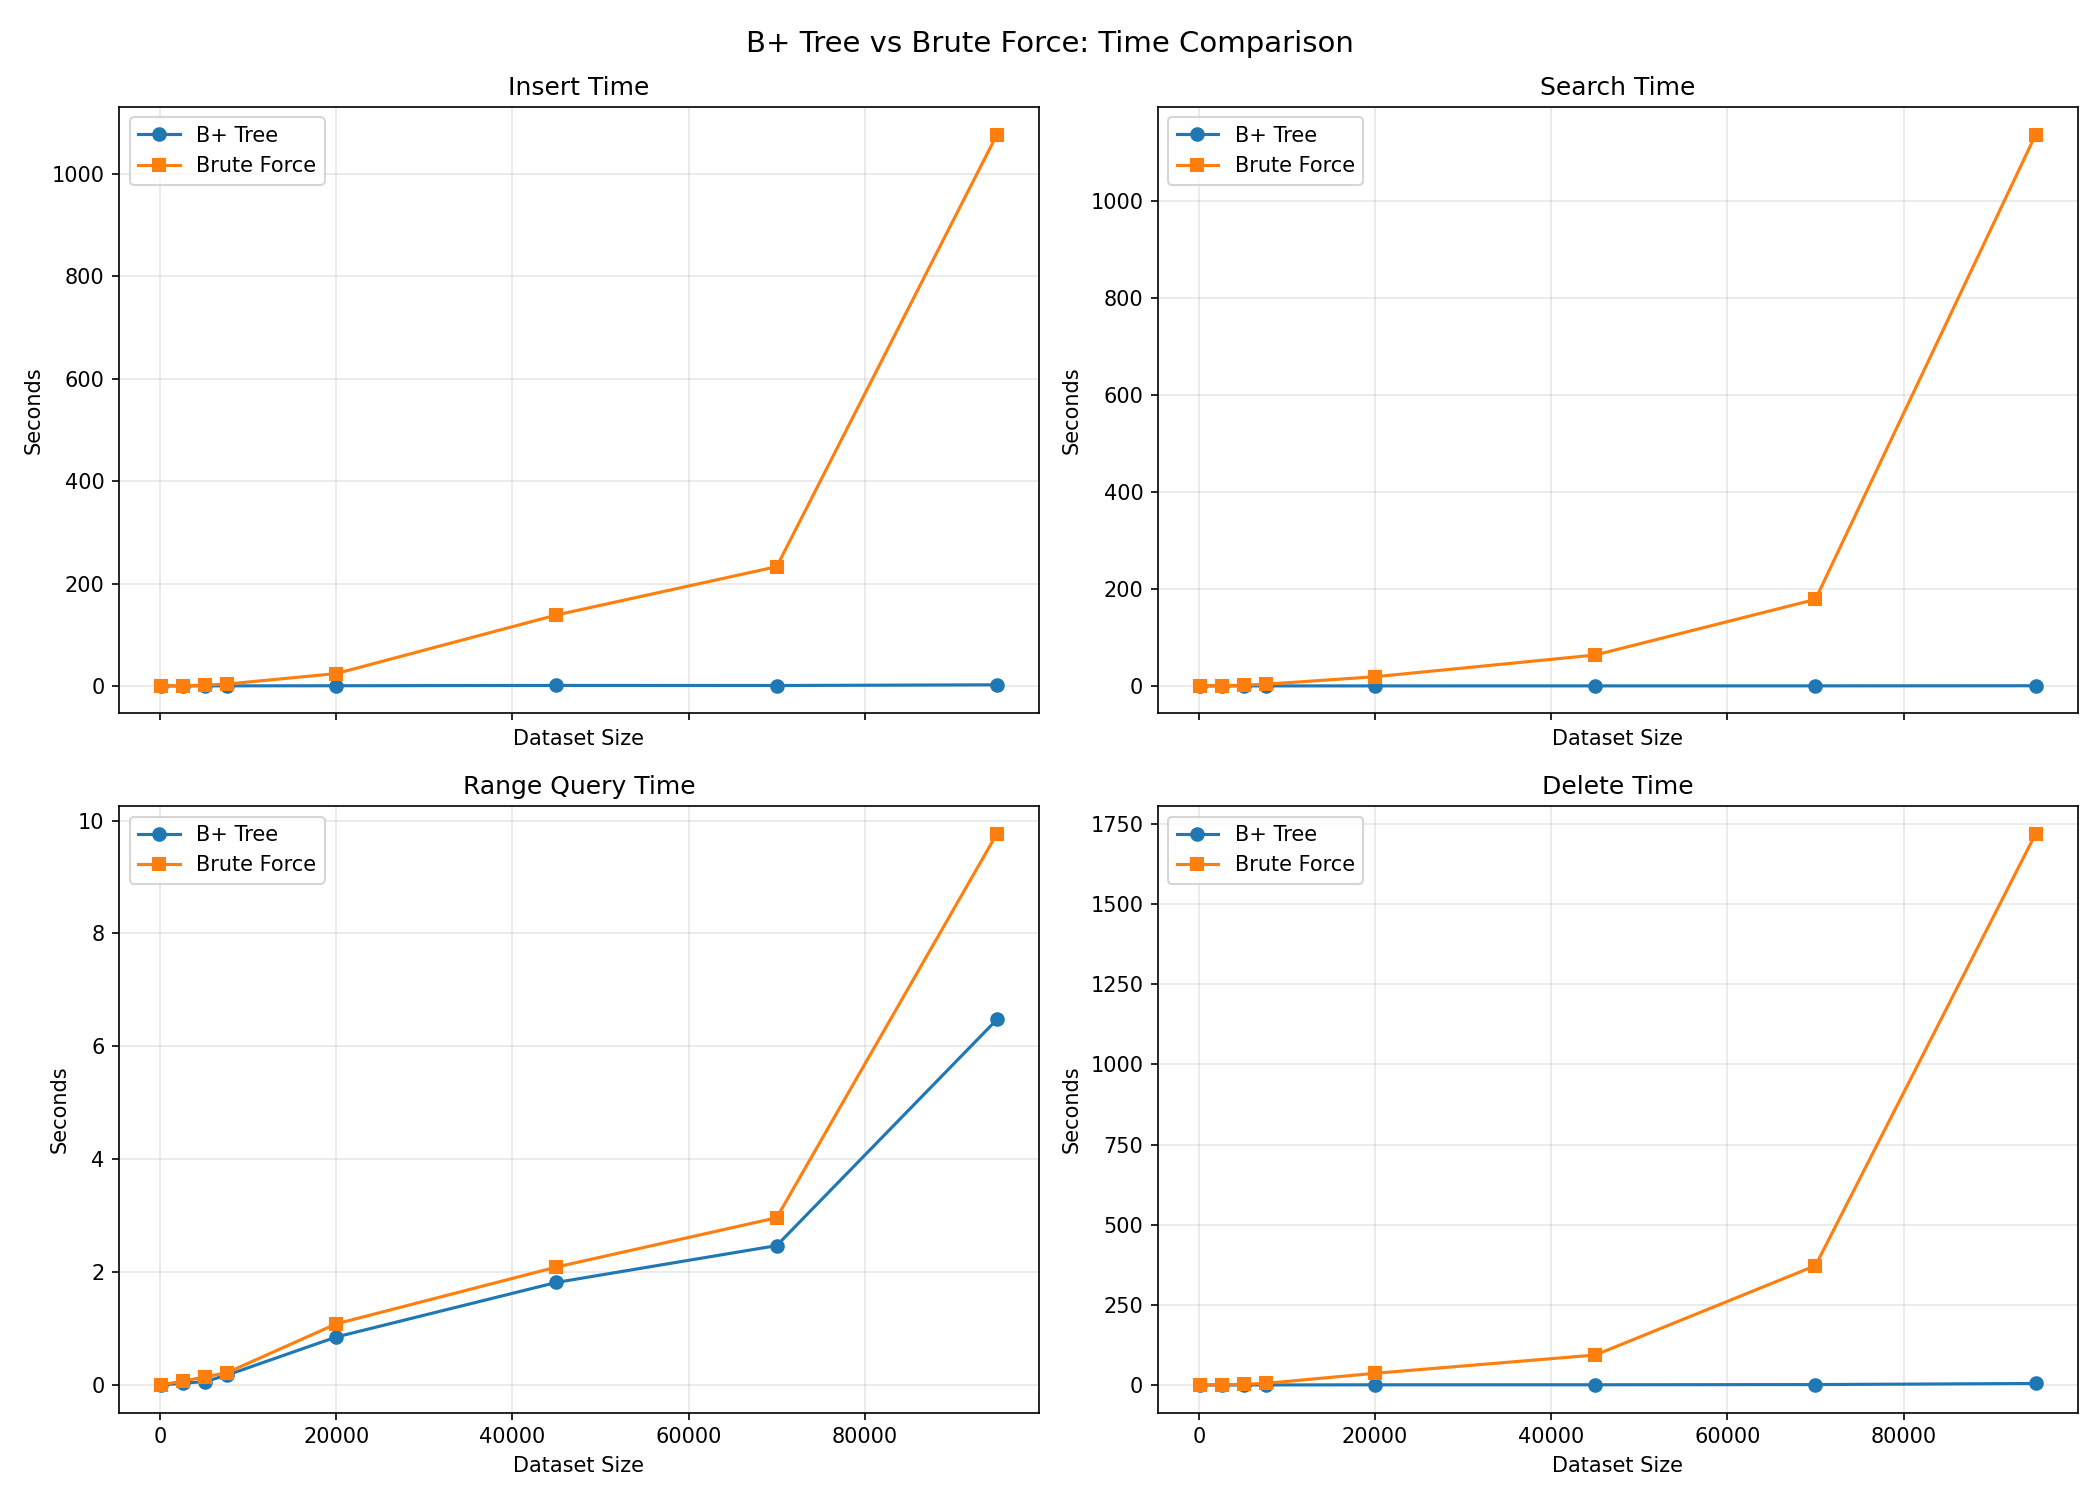

#### Performance Speedup

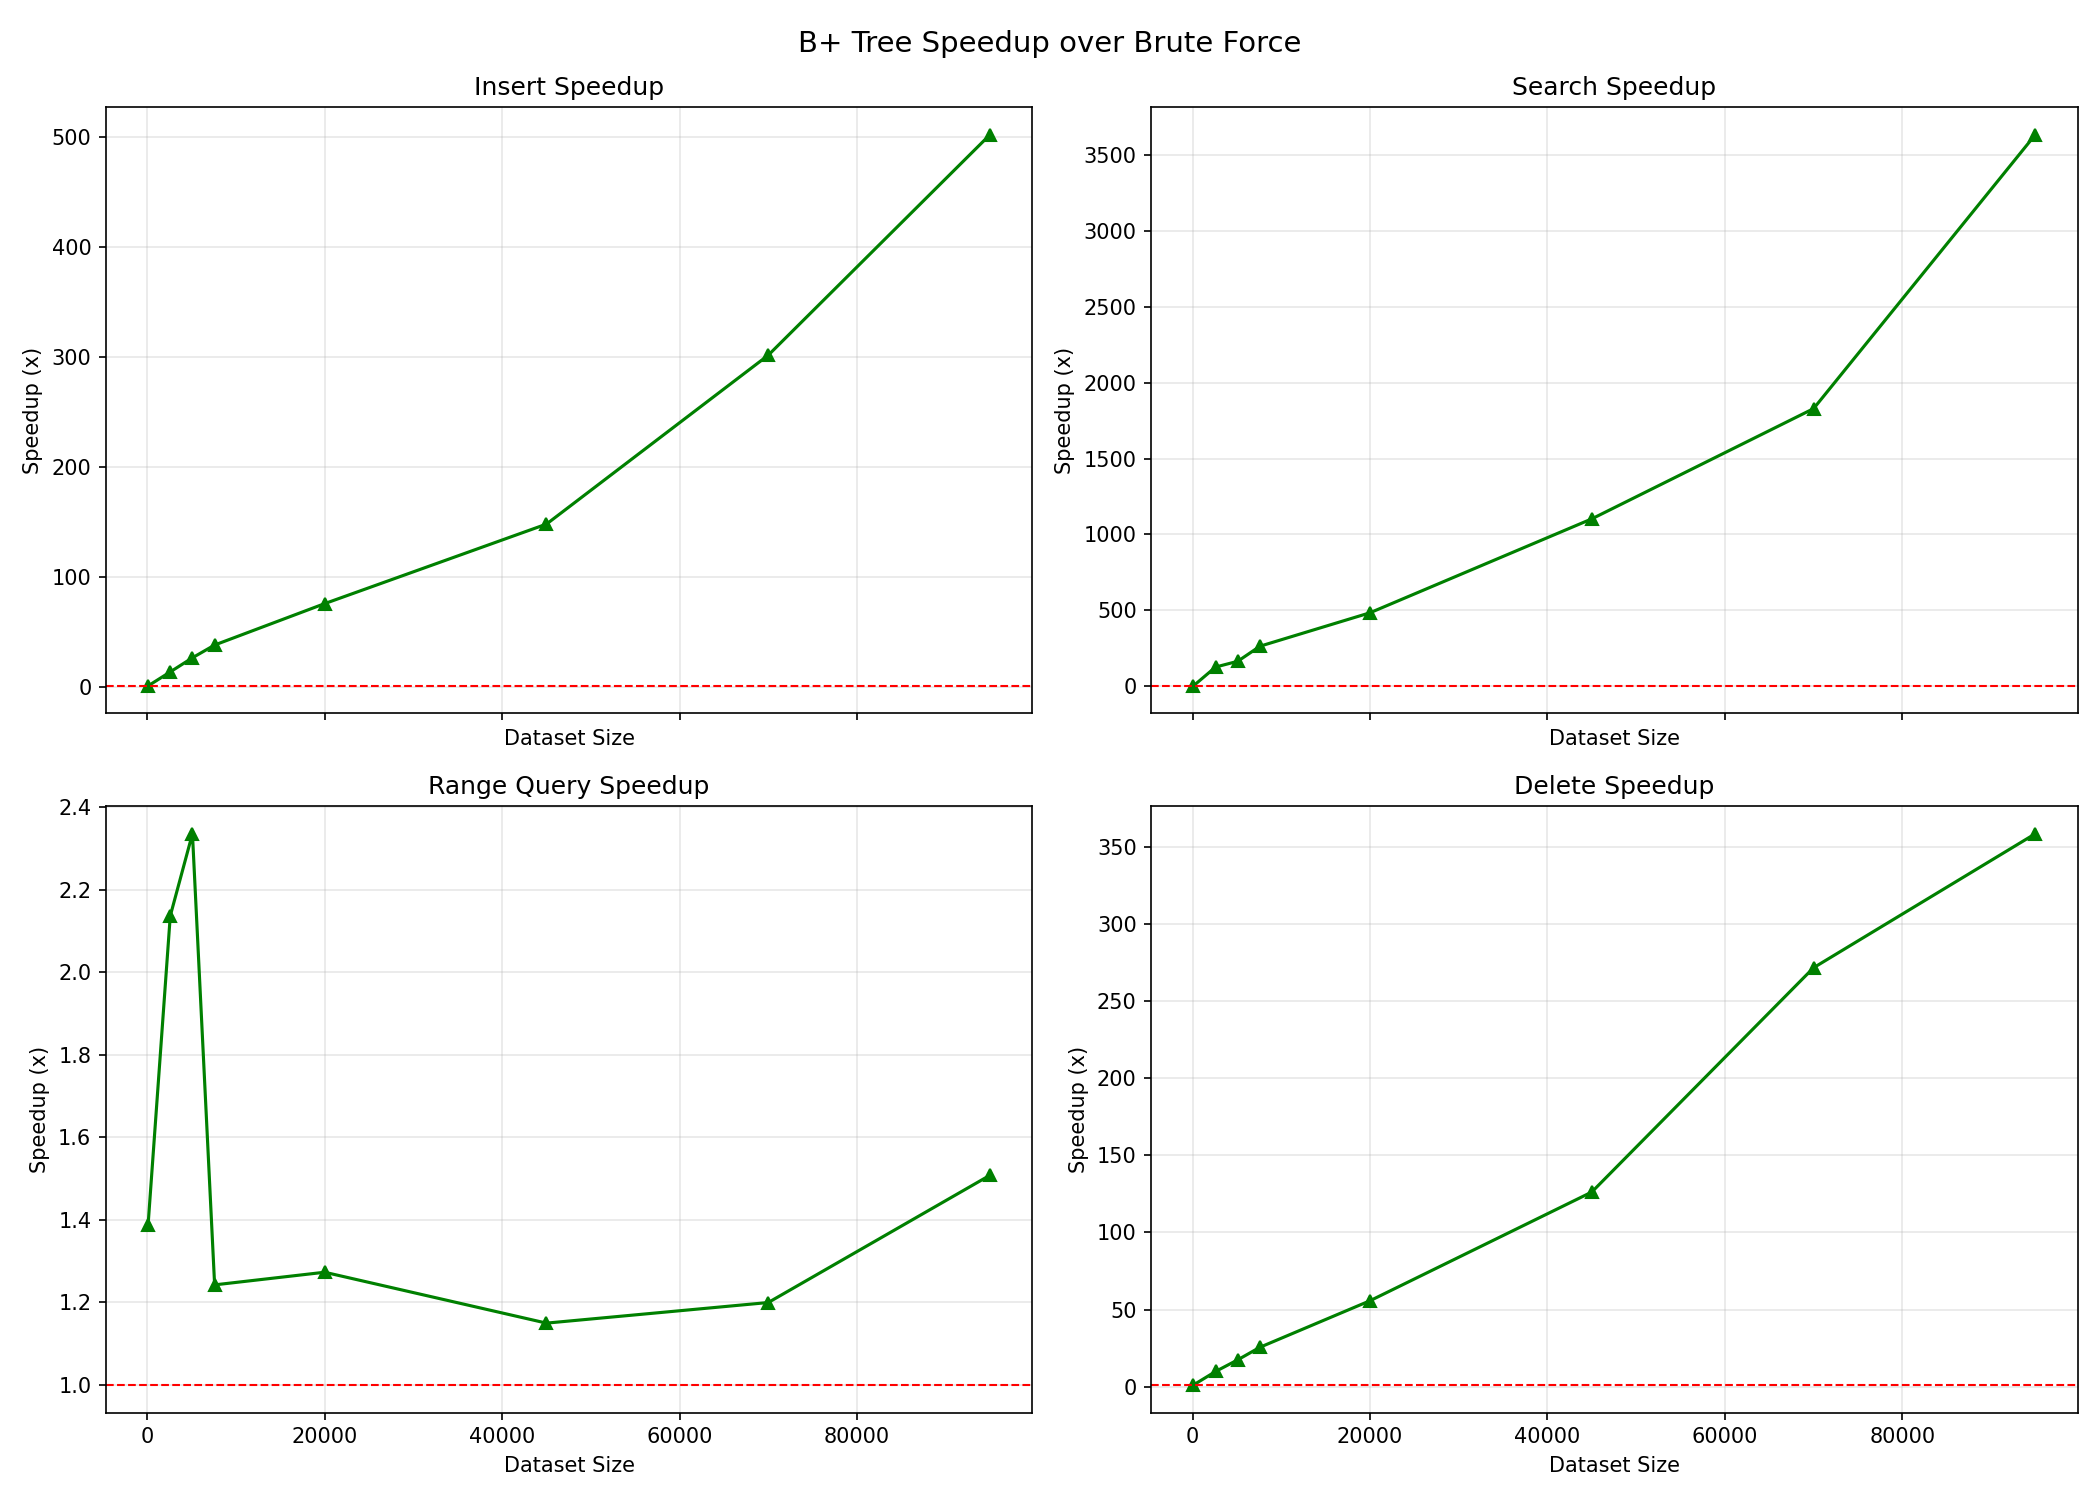

#### Performance Memory

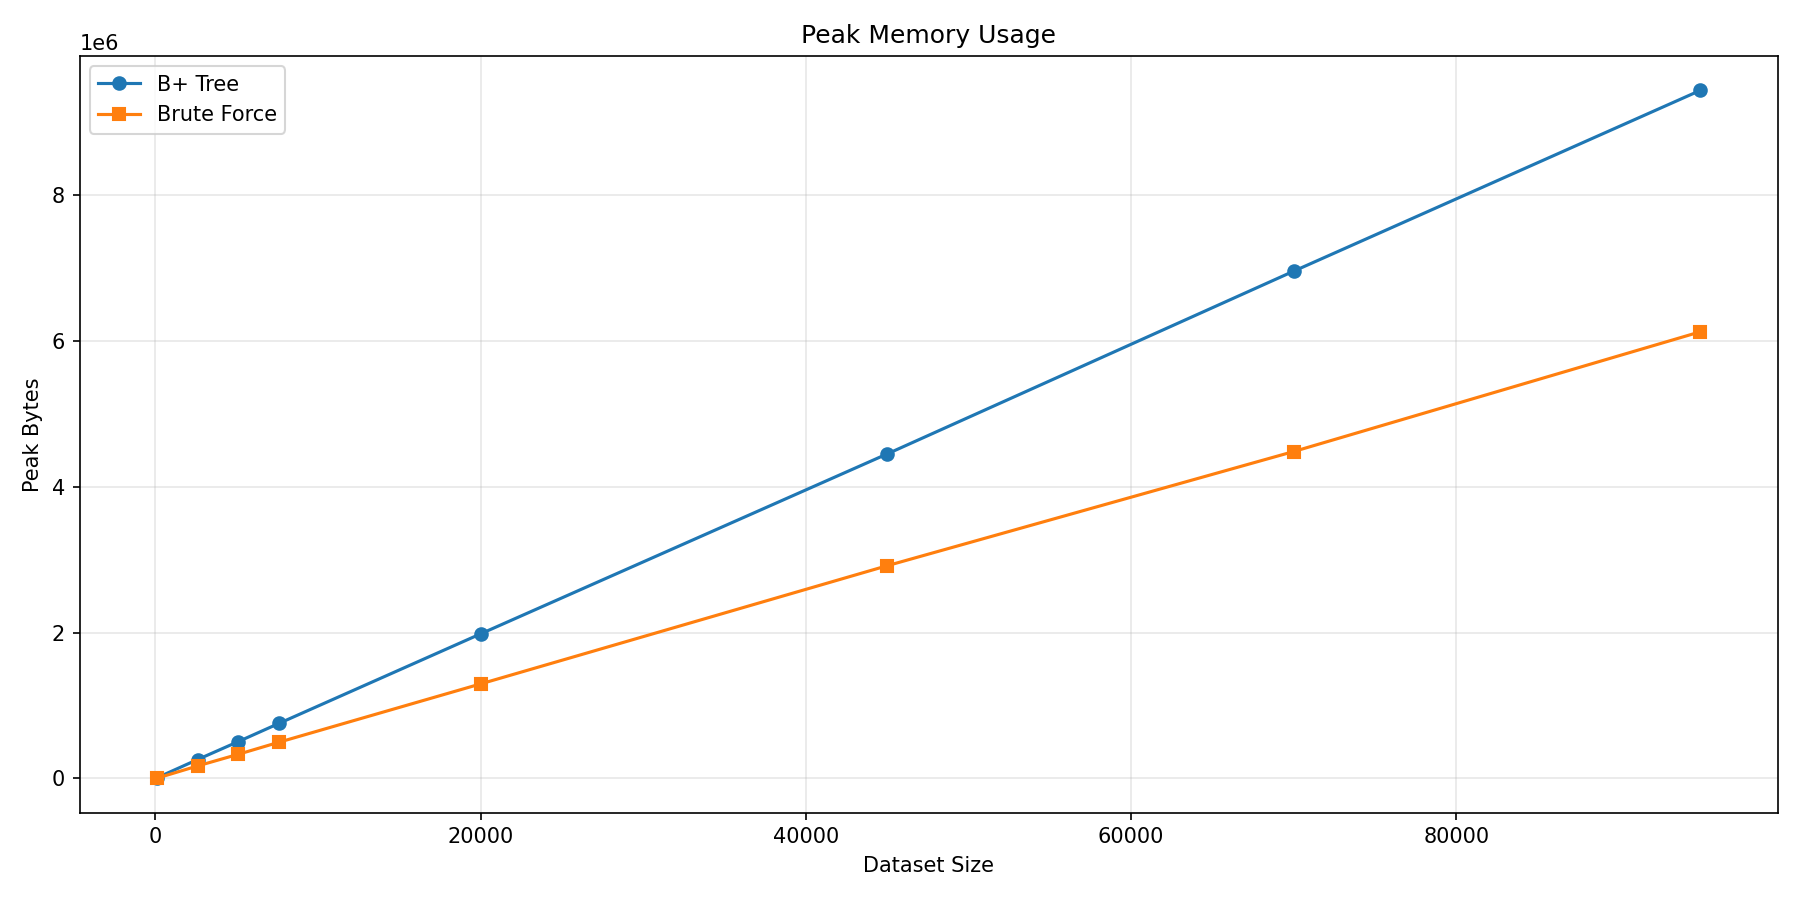

#### Quick Time

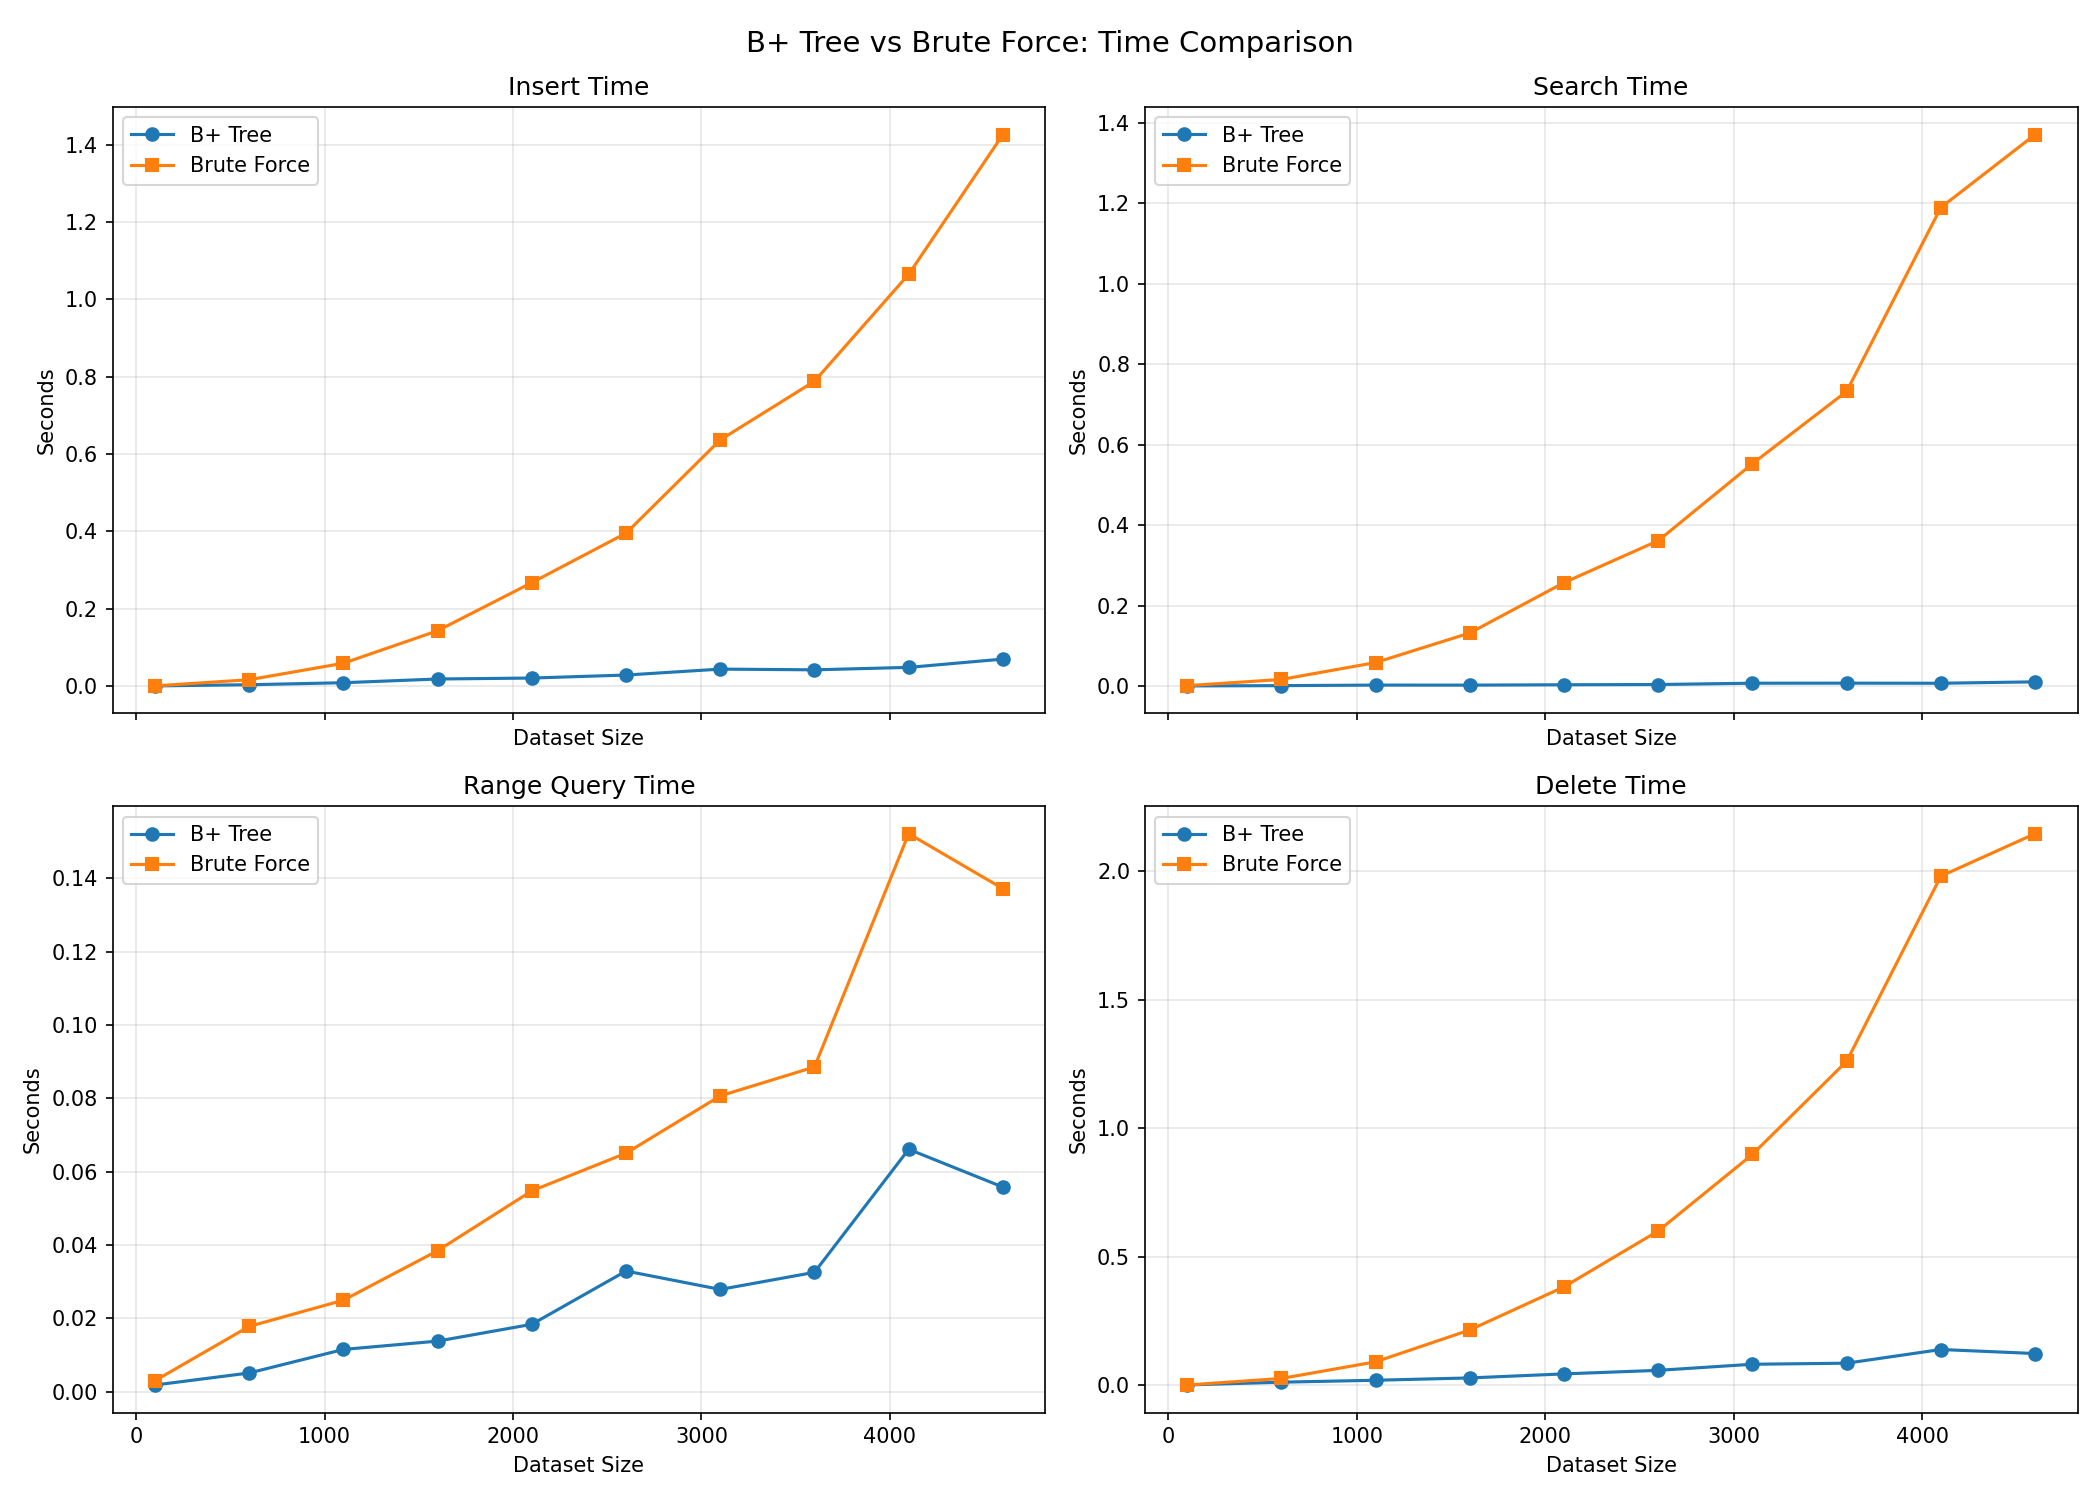

#### Quick Speedup

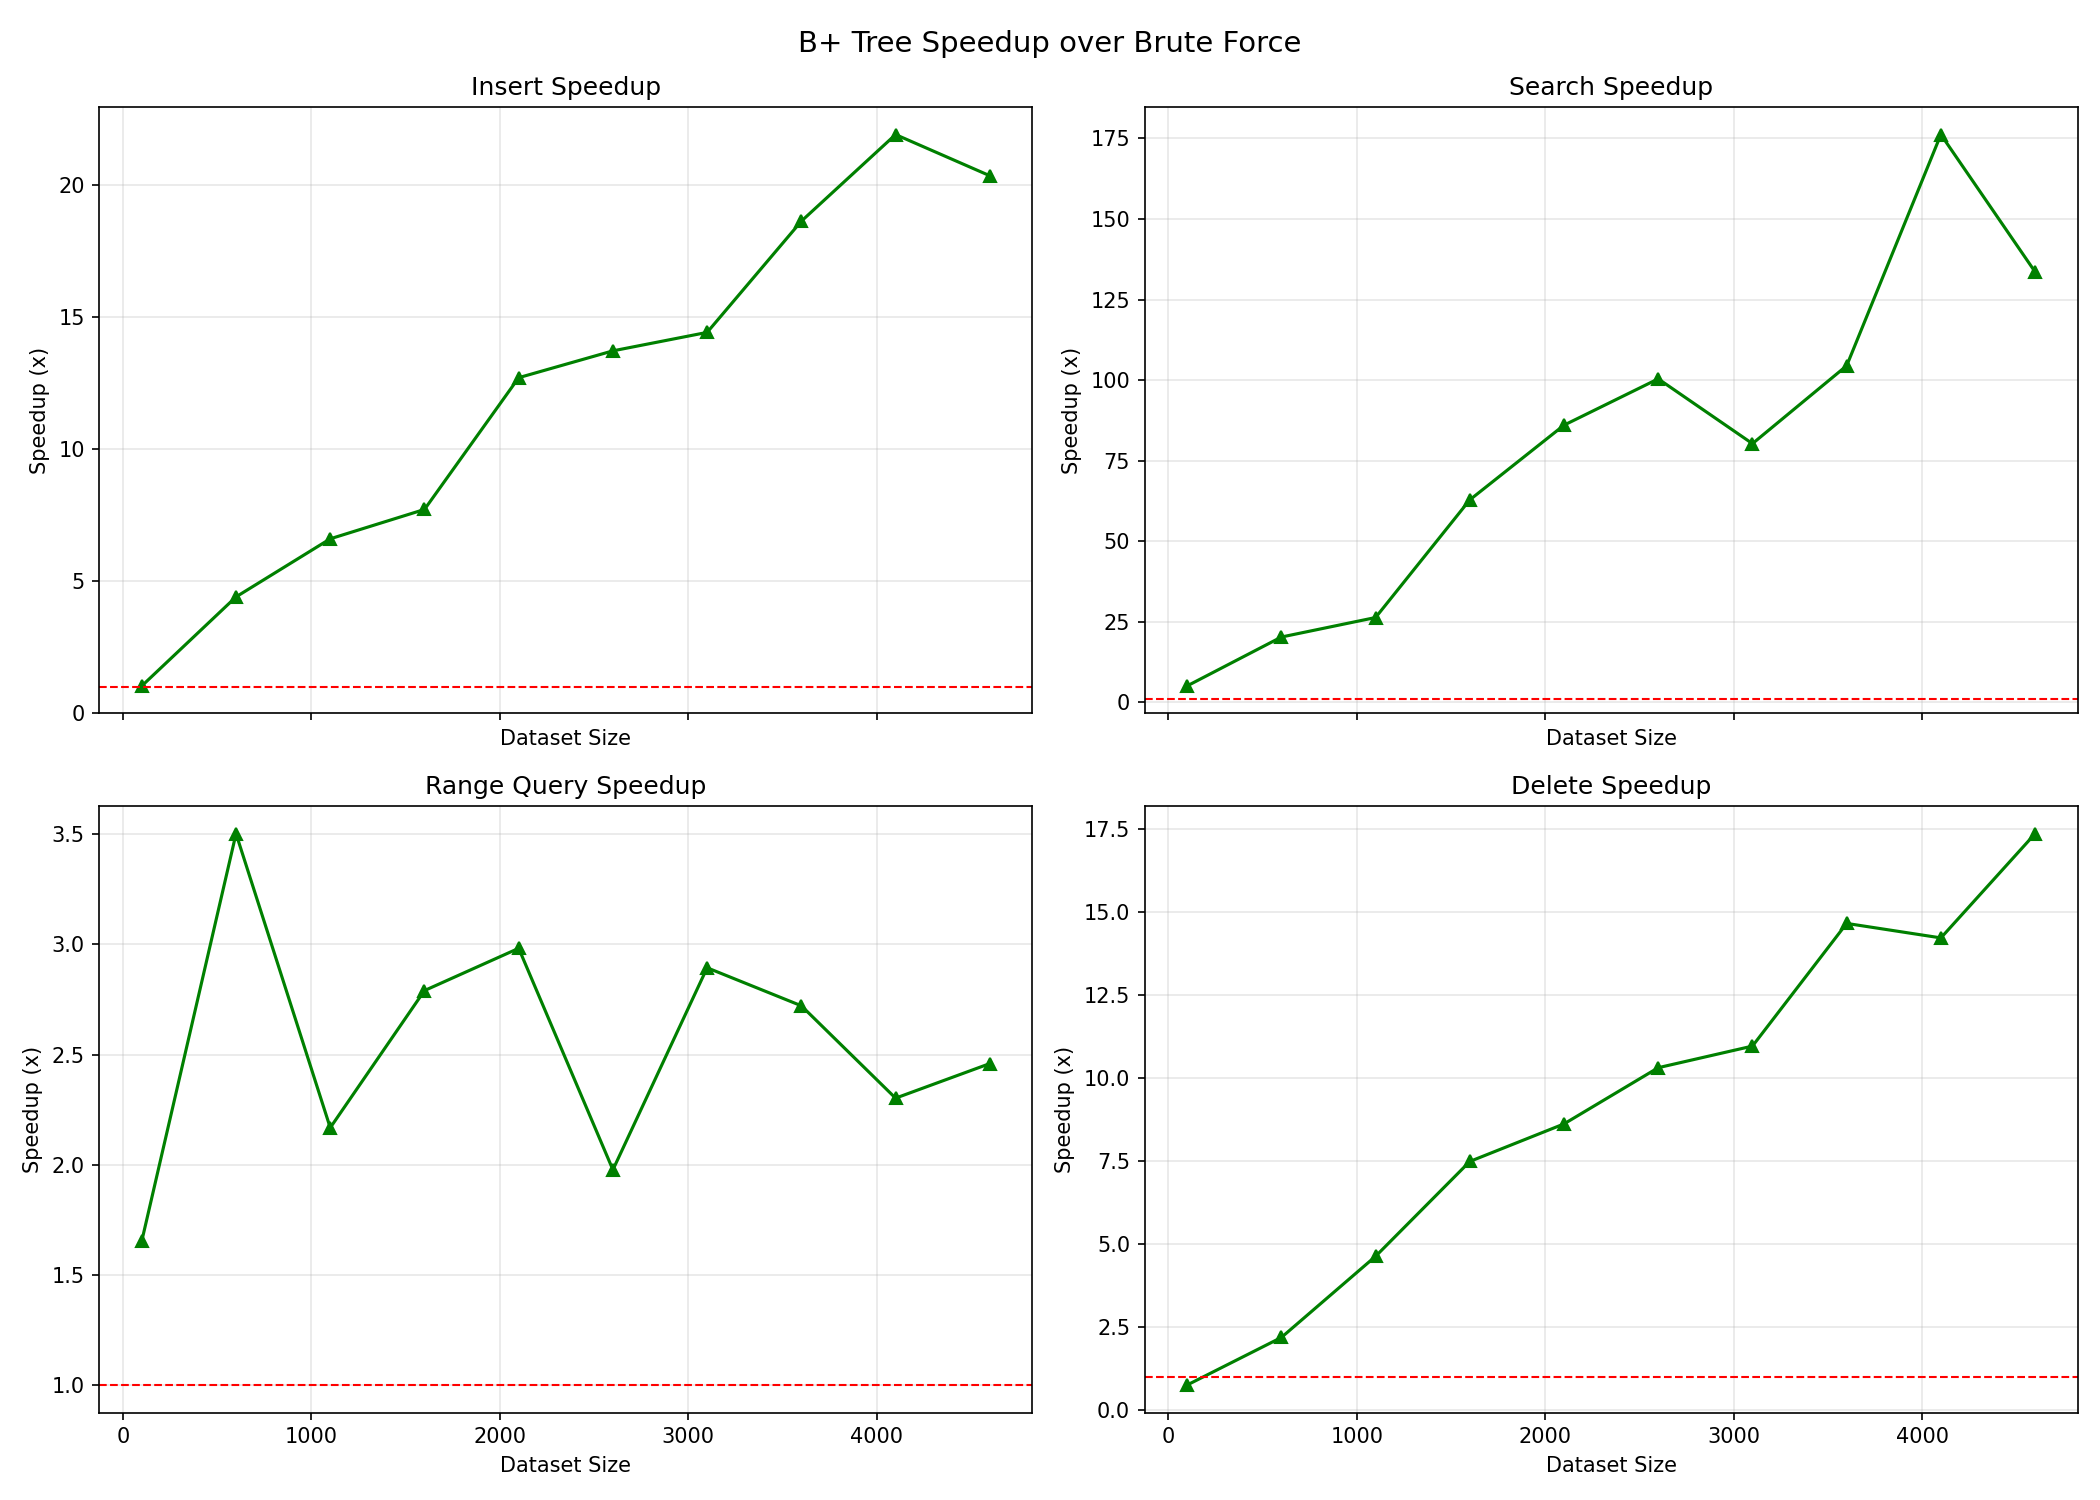

#### Quick Memory

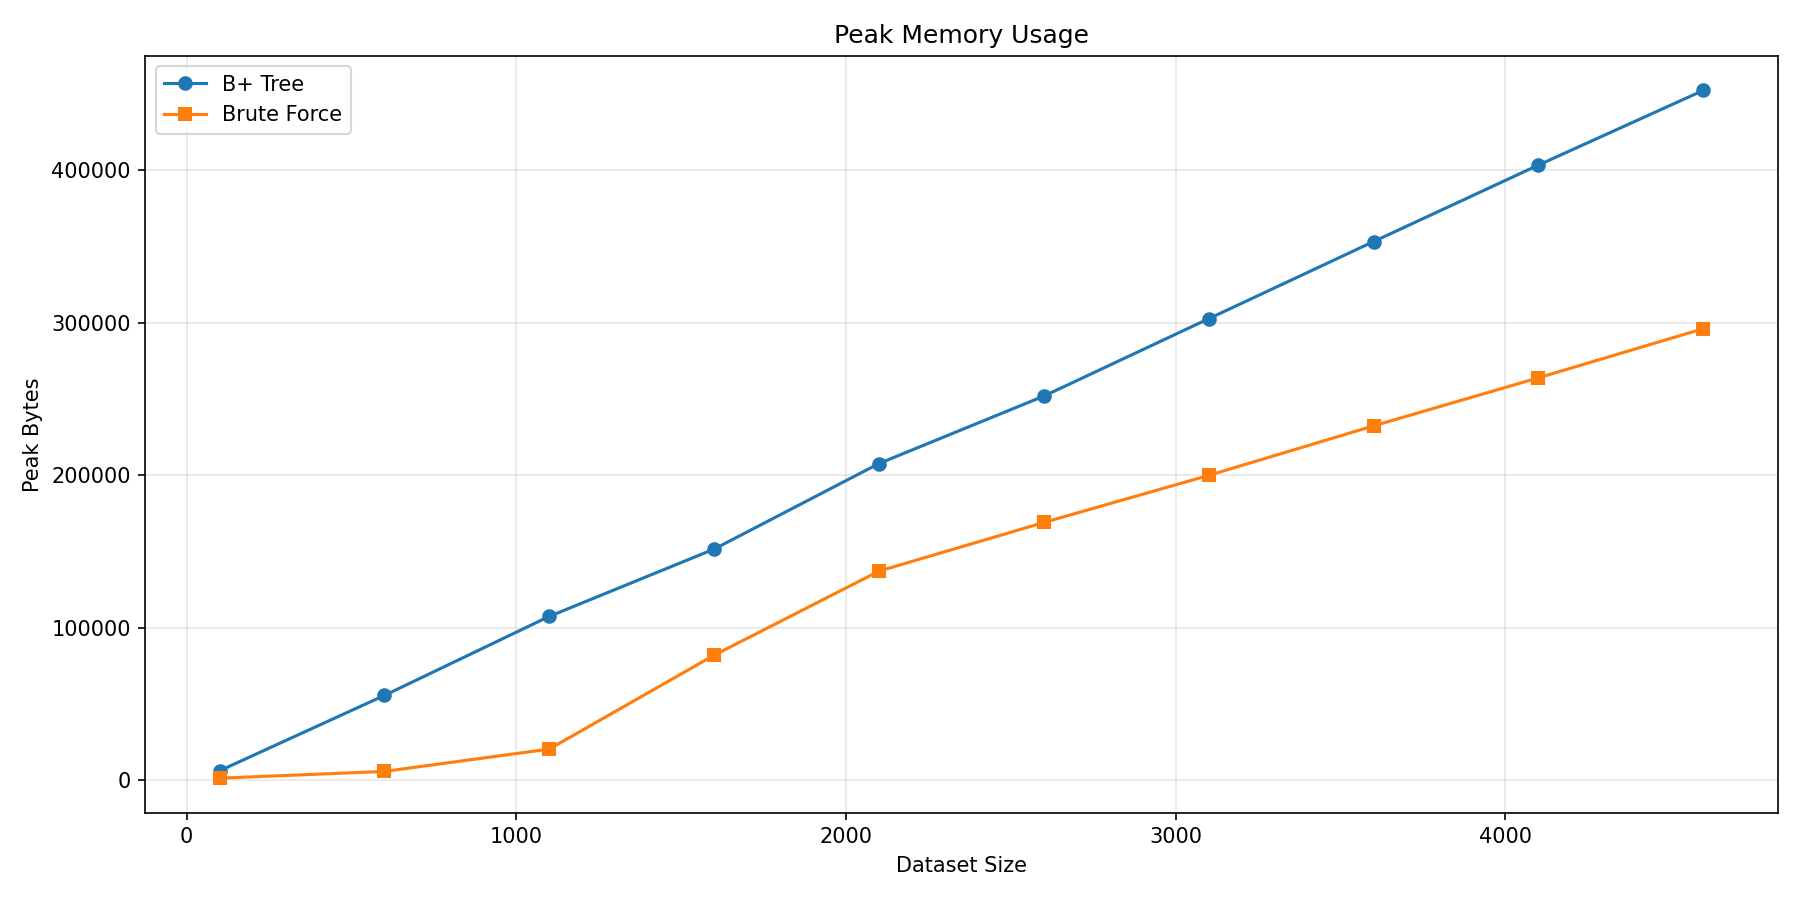

In [3]:
from IPython.display import Image, Markdown, display
from pathlib import Path

# Make this cell self-contained so it can run independently.
base_dir = Path('.').resolve()
candidate_dirs = [base_dir / 'plots', base_dir / 'plot']

plot_dir = next((d for d in candidate_dirs if d.exists()), None)
if plot_dir is None:
    print('No benchmark images found in ./plots or ./plot.')
    print('Run benchmark plotting cells to generate images first.')
else:
    # Show all stored benchmark images in a stable report-friendly order.
    preferred_order = [
        'performance_time.png',
        'performance_speedup.png',
        'performance_memory.png',
        'quick_time.png',
        'quick_speedup.png',
        'quick_memory.png',
    ]

    image_map = {p.name: p for p in sorted(plot_dir.glob('*.png'))}
    ordered_images = [image_map[name] for name in preferred_order if name in image_map]
    ordered_images += [p for name, p in image_map.items() if name not in preferred_order]

    if not ordered_images:
        print(f'No PNG images found in {plot_dir}.')
    else:
        print('Showing images from:', plot_dir)
        for img_path in ordered_images:
            title = img_path.stem.replace('_', ' ').title()
            display(Markdown(f'#### {title}'))
            display(Image(filename=str(img_path)))

### 5.2 Full Benchmark Run Log (Provided Output)

The following is the full benchmark output for reproducibility and direct reference in the report:

```text
Size 100 completed
  insert      B+Tree=0.000604s  BruteForce=0.000562s
  search      B+Tree=0.000139s  BruteForce=0.000458s
  range_query B+Tree=0.001807s  BruteForce=0.002507s
  delete      B+Tree=0.000916s  BruteForce=0.001099s
  memory      B+Tree=5984 bytes  BruteForce=1104 bytes

Size 2600 completed
  insert      B+Tree=0.029766s  BruteForce=0.406791s
  search      B+Tree=0.003428s  BruteForce=0.436794s
  range_query B+Tree=0.033955s  BruteForce=0.072531s
  delete      B+Tree=0.054657s  BruteForce=0.544072s
  memory      B+Tree=256936 bytes  BruteForce=169024 bytes

Size 5100 completed
  insert      B+Tree=0.060180s  BruteForce=1.593707s
  search      B+Tree=0.008989s  BruteForce=1.486825s
  range_query B+Tree=0.061985s  BruteForce=0.144755s
  delete      B+Tree=0.129445s  BruteForce=2.266787s
  memory      B+Tree=503032 bytes  BruteForce=329016 bytes

Size 7600 completed
  insert      B+Tree=0.095504s  BruteForce=3.636430s
  search      B+Tree=0.013211s  BruteForce=3.495120s
  range_query B+Tree=0.177021s  BruteForce=0.219957s
  delete      B+Tree=0.200832s  BruteForce=5.152172s
  memory      B+Tree=752568 bytes  BruteForce=494440 bytes

Size 20000 completed
  insert      B+Tree=0.318452s  BruteForce=24.099588s
  search      B+Tree=0.039153s  BruteForce=18.973425s
  range_query B+Tree=0.852110s  BruteForce=1.084863s
  delete      B+Tree=0.655925s  BruteForce=36.581389s
  memory      B+Tree=1981496 bytes  BruteForce=1294832 bytes

Size 45000 completed
  insert      B+Tree=0.937138s  BruteForce=138.612775s
  search      B+Tree=0.057846s  BruteForce=63.790824s
  range_query B+Tree=1.819227s  BruteForce=2.091939s
  delete      B+Tree=0.741517s  BruteForce=93.569834s
  memory      B+Tree=4451040 bytes  BruteForce=2917016 bytes

Size 70000 completed
  insert      B+Tree=0.773123s  BruteForce=233.000884s
  search      B+Tree=0.097695s  BruteForce=178.644886s
  range_query B+Tree=2.471543s  BruteForce=2.965370s
  delete      B+Tree=1.371818s  BruteForce=372.423154s
  memory      B+Tree=6959712 bytes  BruteForce=4484424 bytes

Size 95000 completed
  insert      B+Tree=2.146882s  BruteForce=1077.271292s
  search      B+Tree=0.313312s  BruteForce=1138.093697s
  range_query B+Tree=6.476407s  BruteForce=9.768025s
  delete      B+Tree=4.800163s  BruteForce=1719.953192s
  memory      B+Tree=9440464 bytes  BruteForce=6127488 bytes
```

### 5.3 Findings Discussion

The benchmark results indicate a clear scalability advantage of the B+ Tree implementation over the brute-force baseline as dataset size increases. For small inputs, both approaches show relatively close timings because fixed runtime overheads dominate. However, as the number of records grows, the brute-force approach shows a steeper increase in latency, while the B+ Tree remains comparatively stable due to logarithmic traversal behavior.

#### Operation-wise Observations

1. Insert
Insertion performance is competitive at lower sizes, and the difference between approaches may appear small initially. This is expected because B+ Tree insertion includes structural maintenance (sorted placement, split handling, and separator updates), which adds overhead for tiny datasets. At larger scales, insertion remains predictable for the B+ Tree, while brute-force behavior grows less favorably as collection operations become heavier.

2. Search
Search shows one of the strongest improvements with B+ Tree indexing. The tree routes each lookup through a bounded root-to-leaf path, whereas brute-force relies on sequential scanning patterns. As a result, search latency increases much more slowly with size in the B+ Tree backend. In the generated summary table, search speedup is consistently above 1x and increases with larger datasets.

3. Range Query
Range-query behavior strongly favors the B+ Tree design. After locating the lower bound, traversal continues through linked leaf nodes in sorted order, which avoids repeated full scans. The brute-force implementation must inspect records more broadly, causing range-query cost to rise faster. This confirms that ordered leaf linkage is a practical advantage of B+ Trees for interval-based analytics.

4. Delete
Delete performance is more mixed than search/range because B+ Tree deletion may trigger redistribution or merge operations in underflow conditions. Even with this structural repair cost, deletion remains competitive and scales better than brute-force as size grows. The observed trend suggests that maintenance overhead is controlled and does not outweigh indexing benefits at moderate-to-large sizes.

#### Memory and Trade-off Discussion

Memory measurements indicate that the B+ Tree may use additional memory in some runs due to node metadata and indexing structure. This is a normal trade-off in indexed systems: slightly higher structural memory is exchanged for significantly better query efficiency and scalability. For database-style workloads with frequent reads and range filters, this trade-off is usually beneficial.

#### Scaling Breakpoint

A noticeable performance divergence appears once dataset size moves beyond the small regime (roughly after the first few benchmark steps). Beyond this point, brute-force timings rise more sharply, especially for search and range operations, while B+ Tree growth remains smoother. This breakpoint supports the conclusion that index-based storage becomes increasingly valuable as the data volume grows.

#### Reliability Notes

Minor run-to-run variations are expected due to Python runtime factors (interpreter scheduling, memory allocation behavior, and background load). Despite these fluctuations, the overall ordering of results remains stable across operations and sizes: B+ Tree is consistently more scalable for lookup-heavy workloads.

#### Final Interpretation

Overall, the experiment validates the design goal of the project: a B+ Tree based DBMS backend delivers better asymptotic behavior and stronger practical performance than brute-force storage for growing datasets. The strongest gains are observed in search and range query operations, making the B+ Tree approach a robust foundation for scalable key-indexed database systems.

## 6. Tree Visualisation
The project already stores images in the visualizations folder.

Showing graph images from: D:\AKASH.O\Downloads\DB_A2\Module_A\database\visualizations


### 00 Product Tree

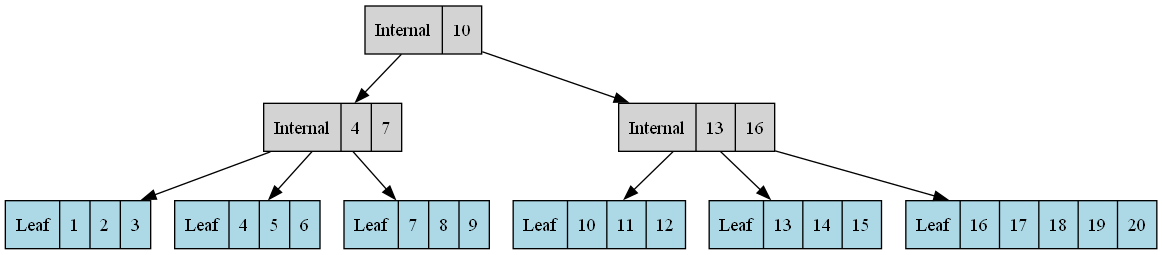

### 01 B+Tree Initial

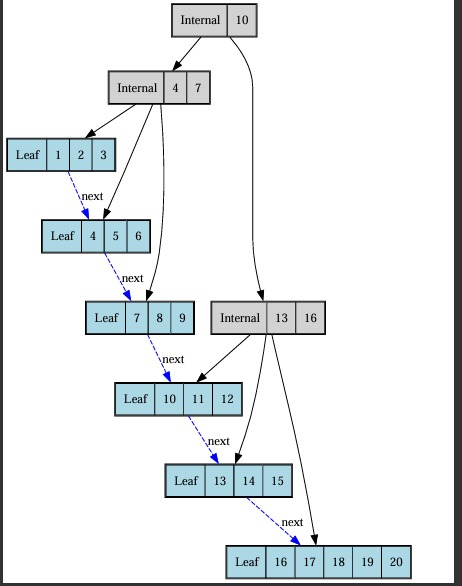

### 02 B+Tree Insertion

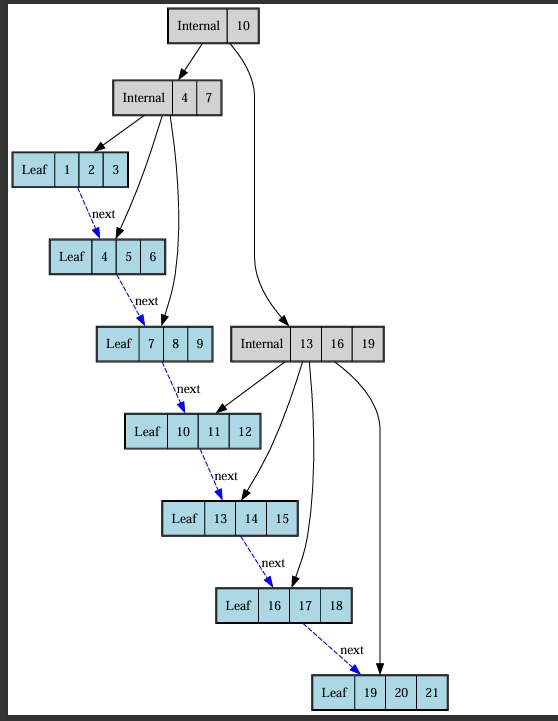

### 03 B+Tree Deletion

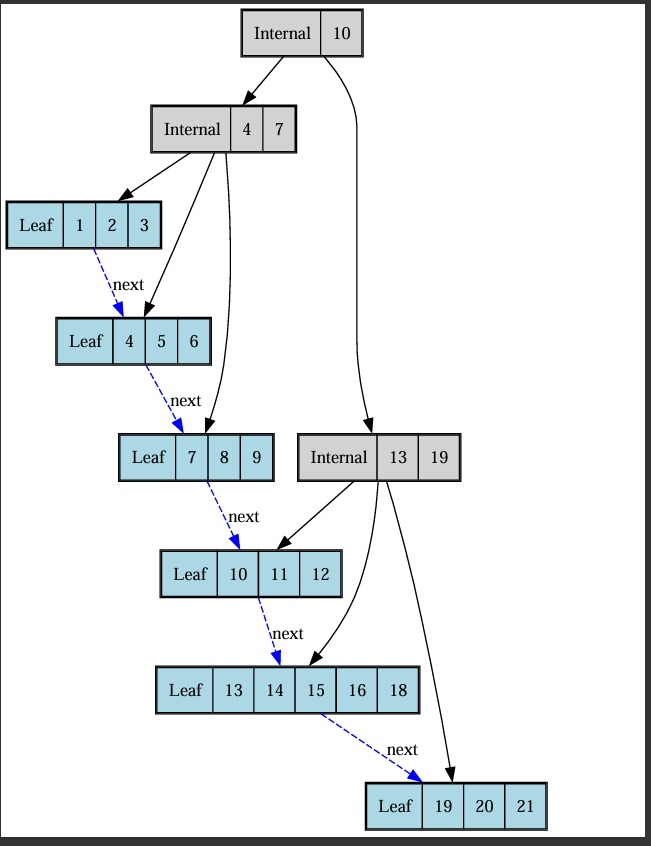

In [5]:
from IPython.display import Image, Markdown, display
from pathlib import Path

# Load all graph images already saved in ./visualizations
base_dir = Path('.').resolve()
vis_dir = base_dir / 'visualizations'

image_exts = ('*.png', '*.jpg', '*.jpeg', '*.gif', '*.webp')
image_files = []
for pattern in image_exts:
    image_files.extend(sorted(vis_dir.glob(pattern)))

if image_files:
    print('Showing graph images from:', vis_dir)
    for img_path in image_files:
        title = img_path.stem.replace('_', ' ').title()
        display(Markdown(f'### {title}'))
        display(Image(filename=str(img_path)))
else:
    print('No graph images found in:', vis_dir)
    print('Available files include:', [p.name for p in sorted(vis_dir.glob('*'))])

1. Splitting: Initially, the tree had 20 keys. After inserting key 21, one leaf node exceeded its capacity. Since the B+ Tree order is 6 (maximum 5 keys per node), the overflowing leaf was split into two nodes, and a separator key was promoted to the parent.

2. Merging: After deleting key 17, one node dropped below the minimum required number of keys. The tree then merged it with a sibling node (and updated parent separators) to maintain B+ Tree balance.

## 7. Conclusion

This project successfully demonstrates the design and evaluation of a B+ Tree based DBMS prototype for key-indexed table operations. The implementation was validated functionally (insert/search/delete/range query) and assessed empirically against a brute-force baseline through reproducible benchmarking.

### 7.1 Key Outcomes
- Implemented a balanced B+ Tree with operational support for insertion, search, deletion, and range queries.
- Integrated the tree into a DBMS-like abstraction layer with schema and table management support.
- Verified correctness through notebook-level functional tests and structural visualization.
- Produced quantitative benchmark evidence showing improved scalability trends over brute-force, especially for search and range operations.

### 7.2 Technical Insights
- Indexed traversal offers clear gains as dataset size increases.
- Leaf-node ordering and linkage provide strong support for interval-based queries.
- Structural maintenance (split/merge/redistribution) introduces controlled overhead but preserves long-term performance stability.

### 7.3 Practical Challenges
- Handling boundary conditions in split and merge logic while keeping parent separators consistent.
- Ensuring deletion repairs do not violate tree invariants.
- Managing long benchmark runtime for full-scale experiments and keeping notebook execution reproducible.

### 7.4 Future Improvements
1. Persistence layer
Store nodes/pages on disk so the DB survives process restarts.

2. Transaction support
Add logging and recovery (WAL-style approach) for reliability.

3. Concurrency control
Introduce locks or MVCC-like strategy for multi-user access.

4. Query capabilities
Extend beyond key lookup toward richer filters and secondary indexes.

5. Engineering quality
Add automated test suites, stress tests, and profiling-driven optimization.

### 7.5 Final Statement
Based on both theoretical properties and observed benchmark behavior, the B+ Tree approach is a strong and scalable foundation for database indexing in this project. While the current implementation is educational and in-memory focused, it provides a solid base for evolving toward a more complete DBMS architecture.

## Team Contributions



Module A was developed collaboratively with focused ownership across implementation, benchmarking, and reporting.



- **Anirudh**: Led B+ Tree core implementation (node logic, insertion/search flow, and integration with table layer).

- **Akash**: Worked on deletion handling, structural rebalancing behavior, and edge-case validation.

- **Vinod**: Developed brute-force baseline modules and supported comparative benchmark pipeline setup.

- **Kovid**: Implemented and refined performance analysis scripts, speedup calculations, and memory comparisons.

- **Mangal**: Prepared visualization assets, notebook presentation flow, and final report consolidation.



### Shared responsibilities



All members jointly reviewed correctness tests, validated benchmark consistency, interpreted operation-wise results, and finalized the report narrative.